In [40]:
import numpy as np
from scipy import sparse # Use sparse matrix for A to be able to use greater values of m
import matplotlib.pyplot as plt

# Only show numbers with 4 decimal points in print
np.set_printoptions(
    formatter={'float_kind': lambda x: f"{x:.4f}"}
)


# Variant 2

Implement a Python function to solve the **Poisson problem** on a square domain with homogeneous Dirichlet and Neumann boundary conditions, using the **5-point finite difference Laplacian**:

$$
\nabla^2 u = f,
\qquad (x, y) \in [a, b] \times [c, d],
$$

with
$$
u(x,c) = g_c(x), \quad u(x, d) = g_d(x), \quad u(a,y) = g_a(y), \quad u_x(b,y) = g_b(y).
$$

### (a) Implement the solver


In [41]:

def poisson_generalized_Neumann(m_x, m_y, a, b, c, d, f=None, g=None):
    """
    Solve the 2D Poisson equation:
        ∇²u = f,   (x,y) ∈ [a,b] × [c,d],

        Dirichlet BCs:
            u(a,y) = g_a(y)
            u(x,c) = g_c(x)
            u(x,d) = g_d(x)

        Neumann BC:
            u_x(b,y) = g_b(y)

        The Neumann boundary condition is treated using
        a ghost point.
    """

    # Step 1: Discretize domain [a,b] × [c,d]

    X = np.linspace(start=a, stop=b, num=m_x+2)
    Y = np.linspace(start=c, stop=d, num=m_y+2)

    hx = X[1]-X[0]
    hy = Y[1]-Y[0]


    # Step 2: Build sparse matrix A for the 5-point Laplacian

    A = np.zeros((m_x*m_y, m_x*m_y))

    for j in range(m_y):
        for i in range(m_x):

            k = m_x*j + i

            # Set entries of A:

            # Interior points
            if i < m_x-1:
                A[k,k] = -2/hx**2 - 2/hy**2
            else:
                # Last interior point in x:
                # ghost point treatment
                A[k,k] = -1/hx**2 - 2/hy**2

            # (i-1,j) if not in boundary
            if i > 0:
                A[k,k-1] = 1/hx**2

            # (i+1,j) if not in boundary
            # Only present if this is not the last interior point
            if i < m_x-1:
                A[k,k+1] = 1/hx**2

            # (i,j-1) if not in boundary
            if j > 0:
                A[k,k-m_x] = 1/hy**2

            # (i,j+1) if not in boundary
            if j < m_y-1:
                A[k,k+m_x] = 1/hy**2


    # Finally we use sparse to use a sparse array
    A = sparse.csr_matrix(A)


    # Step 3: Assemble RHS vector

    if f == None:
        f = lambda x,y: -2*np.sin(x)*np.sin(y)


    if g == None:

        g = {
            "a": lambda y: 0,  # Dirichlet at x=a
            "b": lambda y: 0,  # Neumann at x=b: u_x(b,y)=0
            "c": lambda x: 0,  # Dirichlet at y=c
            "d": lambda x: 0   # Dirichlet at y=d
        }


    rhs = np.zeros(m_x*m_y)

    for j in range(m_y):

        y = Y[j+1]

        for i in range(m_x):

            x = X[i+1]

            k = m_x*j+i

            rhs[k] = f(x,y)


            # ADD BCs

            # Dirichlet at x=a
            if i == 0:
                rhs[k] -= g["a"](y)/hx**2

            # Neumann at x=b
            elif i == m_x-1:
                rhs[k] -= 2*g["b"](y)/hx # Bc of Ghost Point


            # Dirichlet at y=c
            if j == 0:
                rhs[k] -= g["c"](x)/hy**2

            # Dirichlet at y=d
            elif j == m_y-1:
                rhs[k] -= g["d"](x)/hy**2


    # Step 4: Solve linear system AU = F

    U_vector = sparse.linalg.spsolve(A, rhs)


    # Step 5: Reconstruct solution including boundary values

    U = np.zeros((m_x+2, m_y+2))


    # Dirichlet BCs
    U[:,0] = g["c"](X)
    U[:,-1] = g["d"](X)

    U[0,:] = g["a"](Y)


    # Neumann boundary x=b:
    # second-order approximation of u(b,y)
    for j in range(m_y+2):

        y = Y[j]

        if j == 0 or j == m_y+1: # Boundaries for c and d already done
            continue

        U[-1,j] = (
            4*U_vector[m_x*j-1]
            - U_vector[m_x*j-2]
            - 2*hx*g["b"](y)
        )/3


    # Inner points
    for j in range(m_y):

        for i in range(m_x):

            k = m_x*j + i

            U[i+1,j+1] = U_vector[k]


    return X, Y, U

Compare if the code is the same than Task 5 for that problem:

In [42]:
def dist_l2(u_approx, u_exact, h_x, h_y):
    """Returns the normalized l2 norm of the error. 
    
        The real l2 norm would be
            np.sqrt(np.sum((u_approx-u_exact)**2))
        
        The normalized one is
            np.sqrt(h_x * h_y * np.sum((u_approx-u_exact)**2))
            
        with h_x, h_y the size step in x and y coordinates respectively.

    Args:
        u_approx (1D ndarray): Approximation of u
        u_exact (1D ndarray): Exact value of u
        h_x (float): step size in x
        h_y (float): step size in y

    Returns:
        1D ndarray: L2 Error
    """
    return np.sqrt(h_x * h_y * np.sum((u_approx-u_exact)**2))

def dist_linf(u_approx, u_exact):
    return np.max(np.abs(u_approx - u_exact))

def apply_exact(X, Y, u):
    """Apply u to the grid

    Args:
        X, Y : 1D ndarrays
                Meshgrid of all grid points including boundaries.
        u (function): function to evaluate
        
    Returns
        U: 2D ndarrays
                Evaluation of U in the grid
    """
    
    # We may have different lengths
    n = len(X)
    m = len(Y)
    
    U = np.zeros((n, m))
    
    for i in range(n):
        x = X[i]
        for j in range(m):
            y = Y[j]
            U[i,j] = u(x, y)
            
    
    # Also can use np.meshgrid in the following way:
    #     XX, YY = np.meshgrid(X, Y, indexing="ij")
    #     U = u (XX, YY)
    
    return U

## Plots

Now I am going to plot the results for a different BC.

In [43]:
def plot_surface(X, Y, U):
    
    fig = plt.figure() # fig saves the figure in case we want to do something
    ax = plt.axes(projection = "3d")

    X_grid, Y_grid = np.meshgrid(X, Y, indexing="ij")

    ax.plot_surface(X_grid, Y_grid, U, cmap = "viridis") # ax.plot3D plots lines between points, not the surface. 
    # Use it for curves
        

    plt.show()

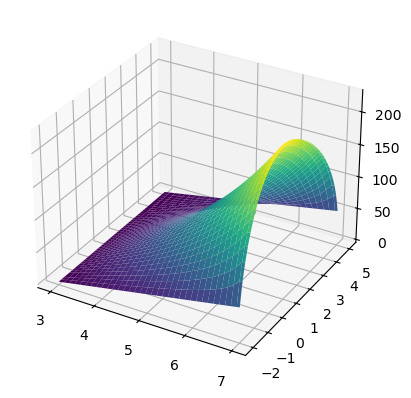

In [44]:

# I am going to use a tilted plane as base 
a = 3
b = 7
c =-2
d = 5

# First example
f = lambda x, y: x*y

slope = 50
g = {
    "a": lambda y: 0,
    "b": lambda y: slope,
    "c": lambda x: slope*(x-a)/(b-a),
    "d": lambda x: slope*(x-a)/(b-a)
}


m_x = 64
m_y = 128

X, Y, U = poisson_generalized_Neumann(m_x, m_y, a, b, c, d, f = f, g = g)

fig = plt.figure()
ax = plt.axes(projection = "3d")

X_grid, Y_grid = np.meshgrid(X, Y, indexing="ij")

ax.plot_surface(X_grid, Y_grid, U, cmap = "viridis") # ax.plot3D plots lines between points, not the surface. 
# Use it for curves

plt.show()

What if we want different POVs?

In [45]:
        
def plot_surface_perspectives(X, Y, U, perspective):
    
    number_axes = np.ceil(np.sqrt(len(perspective))).astype(int) # axes will form an square with this number of axes per side
    # print(f"number_axes = {number_axes}")
    
    # Grid to be able to plot
    X_grid, Y_grid = np.meshgrid(X, Y, indexing="ij")
    
    # figsize by default uses inches (which I don't use), so change to cm
    cm = 1/2.54 # 1 inch is 2.54 cm
    # I will leave 10x10 cm to each axis
    fig = plt.figure(figsize = (number_axes*10*cm, number_axes*10*cm))
        
    
    # Divide the figure in a square with same number of axes in each row and column
    
    
    
    i = 1 # Number of the axis we are placing
    for (height, angle) in perspective:
        # instead of using i this way we can use:
        # for i, (elev, azim) in enumerate(perspective, 1) and erase i+=1
        
        ax = fig.add_subplot(number_axes, number_axes, i, projection = "3d") 
        i += 1
        
        ax.plot_surface(X_grid, Y_grid, U, cmap = "viridis") # Plot surface
        
        # Set view point
        ax.view_init(elev = height, azim = angle)
        
        # Set labels
        ax.set_xlabel("x")
        ax.set_ylabel("y")
        ax.set_zlabel("u")
        
    plt.tight_layout() # Controls spacing between axes
    plt.show()
        

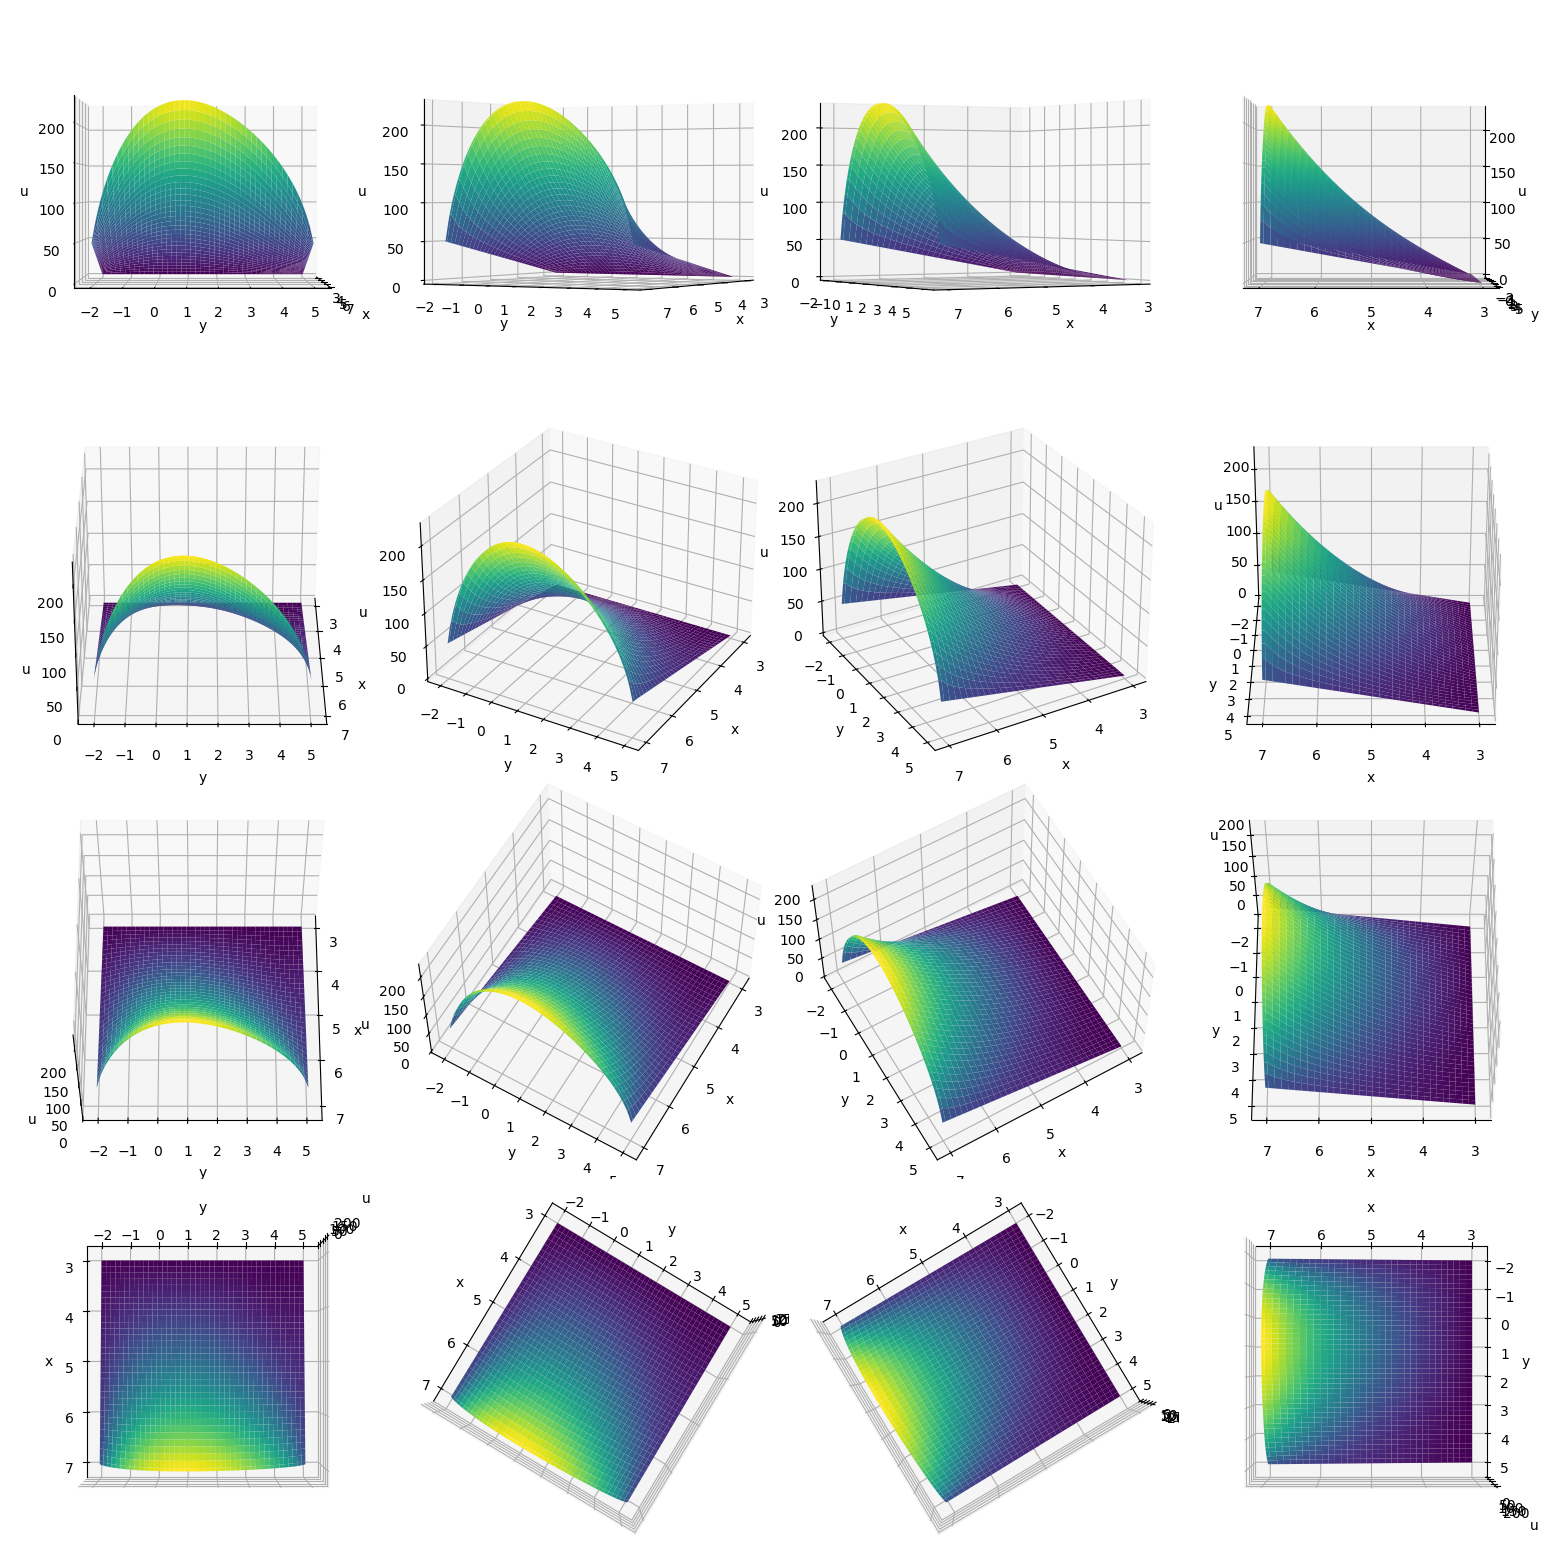

In [46]:

# If we want several perspectives:
perspective = [
    (0, 0), # first number is the elevation of the camera, 2nd is the angle wrt vertical axis
    (0, 30),
    (0, 60),
    (0, 90),
    (30, 0),
    (30, 30),
    (30, 60),
    (30, 90),
    (60, 0),
    (60, 30),
    (60, 60),
    (60, 90),
    (90, 0),
    (90, 30),
    (90, 60),
    (90, 90)
]

plot_surface_perspectives(X, Y, U, perspective)